**Goal**

This project aims to forecast monthly passenger traffic at O.R. Tambo International Airport using econometric, demographics as external indicators. The goal is to understand the drivers of passenger demand and build predictive models to improve forecasting accuracy for aviation planning and resource allocation.


In [63]:
#Importing manipulation and Visualion libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [1110]:
# 1. Set the overall dark background (fixes text/axes colors)
plt.style.use('dark_background')

# 2. Define and apply  specific color palette
sns.set_palette(palette='Paired')

#Add a Seaborn style for better spacing/grid
sns.set_style("ticks") 


In [1219]:
#importing our dataset
data = 'C:/Users/mbuyiselox/Documents/Self learning/Projects/Air Traffic Forecast/Clean datasets/CompleteDataset.csv'
df = pd.read_csv(data)
df.head()

,Date,Passengers,Consumer_spending.Consumer spending,CPI.CPI,Crude_oil.Crude Oil,GDP.GDP,Population.Population,Trade_balance.Trade balance (Rands),Unemployment_rate.Unemployment,Urbanisation.Urbanisation,population_growth.population_growth,tourists.tourists
0,2012/04/01,819885.0,2.793260e+12,6.1,890.44,4.344010e+11,53782567.0,-9.900000e+09,24.84194,63.272,1.474794,802834.0
1,2012/05/01,765773.0,NaN,5.7,846.60,NaN,NaN,-8.900000e+09,NaN,NaN,NaN,692046.0
2,2012/06/01,745731.0,NaN,5.5,761.13,NaN,NaN,-5.700000e+09,NaN,NaN,NaN,653686.0
3,2012/07/01,794131.0,NaN,4.9,798.05,NaN,NaN,-6.700000e+09,25.06654,NaN,NaN,793245.0
4,2012/08/01,791901.0,NaN,5.0,871.23,NaN,NaN,-1.220000e+10,NaN,NaN,NaN,77562.0


## **Data Manipulation and Transformations**

In [1220]:
df = df[['Date', 'Passengers', 'tourists.tourists', 'CPI.CPI', 'GDP.GDP', 'Population.Population']]
df.tail()

,Date,Passengers,tourists.tourists,CPI.CPI,GDP.GDP,Population.Population
163,2025/11/01,900551.0,NaN,3.5,NaN,NaN
164,2025/12/01,1057160.0,997195.0,3.6,NaN,NaN
165,NaN,NaN,NaN,NaN,NaN,NaN
166,NaN,NaN,NaN,NaN,NaN,NaN
167,NaN,NaN,NaN,NaN,NaN,NaN


In [1221]:
df = df.iloc[:-3]

In [1222]:
#Setting the date as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [1223]:
#dding covi19 dummy 
df['covid_flag'] = ((df.index >='2020-03-01') & (df.index < '2021-08-01')).astype(int)

In [1224]:
df.rename(columns ={'Crude_oil.Crude Oil' : 'crude_oil',
                  'tourists.tourists' : 'tourists',
                  'CPI.CPI' : 'cpi',
                  'GDP.GDP' : 'gdp',
                   'Population.Population' : 'population'},
          inplace=True)

In [1225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 165 entries, 2012-04-01 to 2025-12-01
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Passengers  165 non-null    float64
 1   tourists    161 non-null    float64
 2   cpi         164 non-null    float64
 3   gdp         14 non-null     float64
 4   population  14 non-null     float64
 5   covid_flag  165 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 9.0 KB


In [1226]:
#interpolting gdp nd popultion columns
col = ['gdp', 'population']
df[col] = df[col].interpolate(method='linear')

In [1227]:
df.isna().sum()

Passengers    0
tourists      4
cpi           1
gdp           0
population    0
covid_flag    0
dtype: int64

In [1228]:
#front filling tourists and cpi
df['tourists'] = df.tourists.ffill()
df['cpi'] = df.cpi.ffill()

In [1229]:
df['gdp_per_capta'] = df['gdp']/df['population']
df.drop(['population', 'gdp'], axis=1,
        inplace=True)

In [1230]:
df['month'] = df.index.month

In [1231]:
df['covid_flag'].value_counts()

covid_flag
0    148
1     17
Name: count, dtype: int64

In [1232]:
df.isna().sum()

Passengers       0
tourists         0
cpi              0
covid_flag       0
gdp_per_capta    0
month            0
dtype: int64

In [1233]:
df.duplicated().sum()

np.int64(0)

In [1234]:
df.columns

Index(['Passengers', 'tourists', 'cpi', 'covid_flag', 'gdp_per_capta',
       'month'],
      dtype='object')

## **EDA**

<Figure size 1200x600 with 0 Axes>

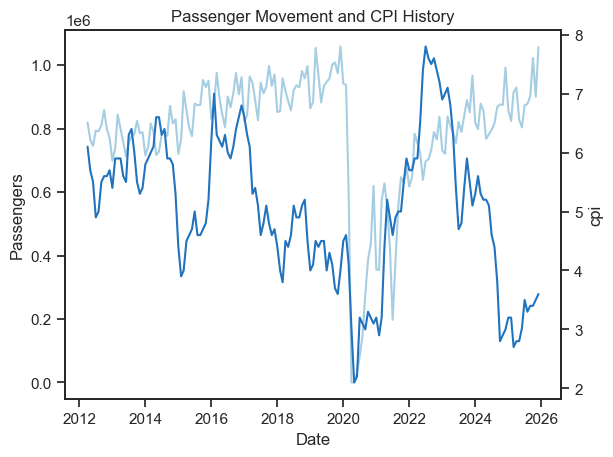

In [1147]:
ax = plt.figure(figsize=(12,6))
fig, ax1 = plt.subplots()
sns.lineplot(data=df, x=df.index, y='Passengers',
            ax = ax1, errorbar=None)

ax2 = ax1.twinx()
sns.lineplot(data=df, x=df.index, y='cpi',
            ax = ax2, errorbar=None, color = "#2073BC")
plt.title("Passenger Movement and CPI History")
plt.show()

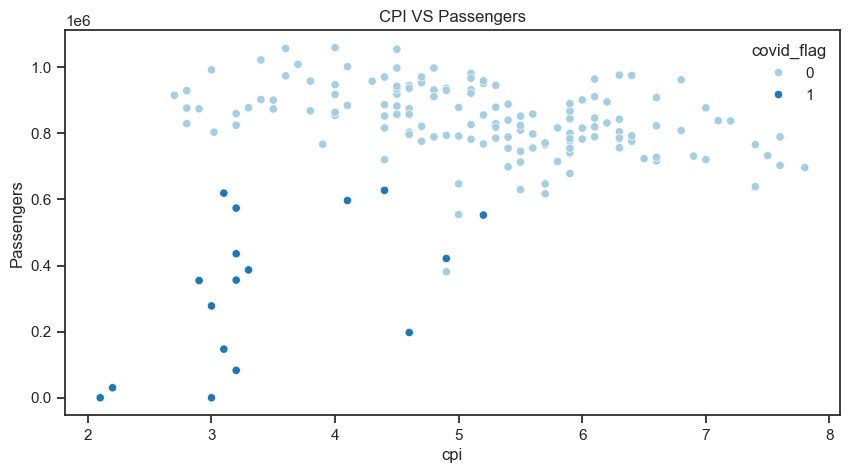

In [1154]:
ax = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x=df['cpi'], y='Passengers',
               hue = 'covid_flag')

plt.title("CPI VS Passengers")
plt.show()

<Figure size 1200x600 with 0 Axes>

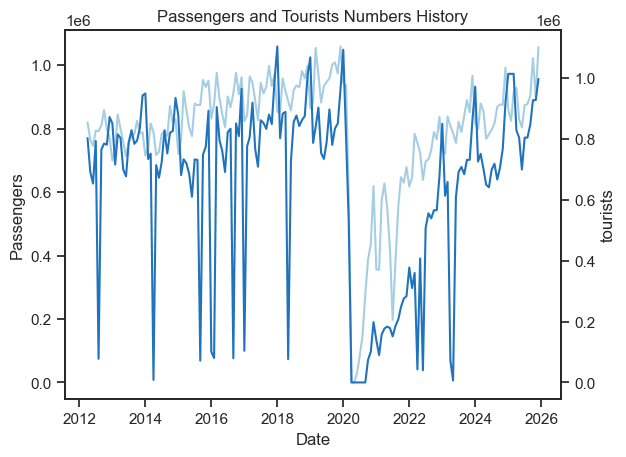

In [1153]:
ax = plt.figure(figsize=(12,6))

fig, ax1 = plt.subplots()
sns.lineplot(data=df, x=df.index, y='Passengers',
            ax = ax1, errorbar=None)

ax2 = ax1.twinx()
sns.lineplot(data=df, x=df.index, y='tourists',
            ax = ax2, errorbar=None, color = "#2073BC")

plt.title("Passengers and Tourists Numbers History")
plt.show()

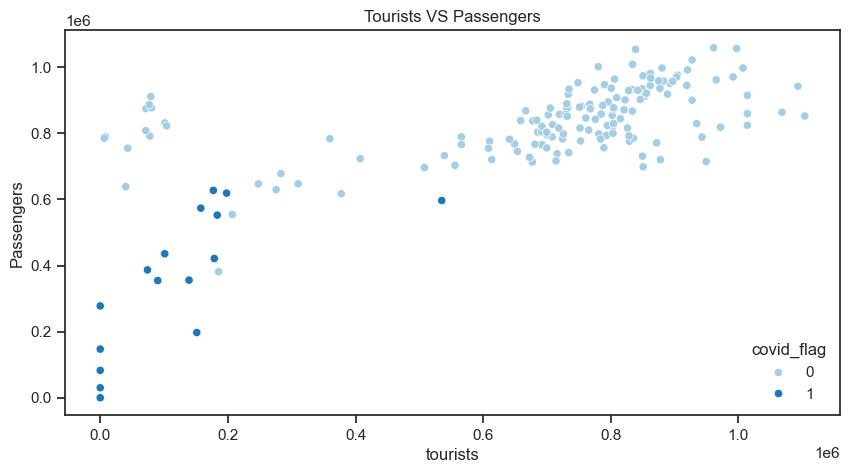

In [1156]:
ax = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x=df['tourists'], y='Passengers',
               hue = 'covid_flag')

plt.title("Tourists VS Passengers")
plt.show()

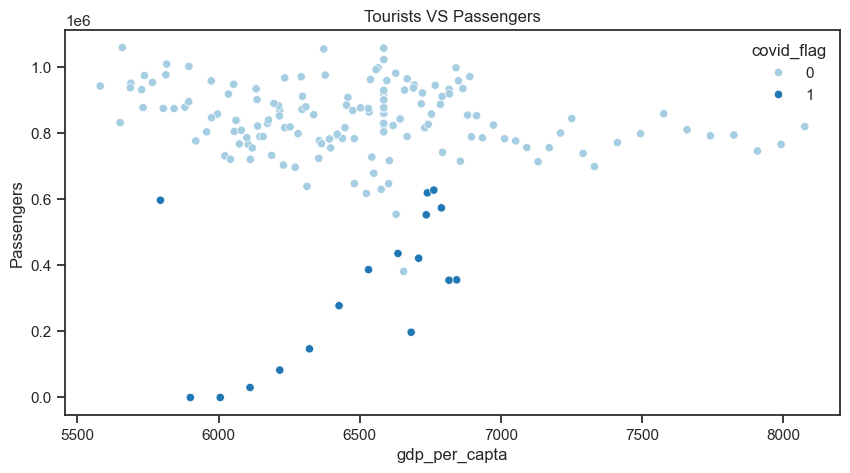

In [1158]:
ax = plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x=df['gdp_per_capta'], y='Passengers',
               hue = 'covid_flag')

plt.title("Tourists VS Passengers")
plt.show()

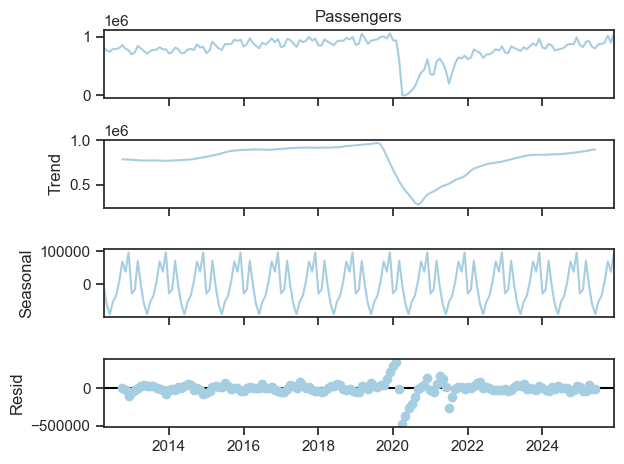

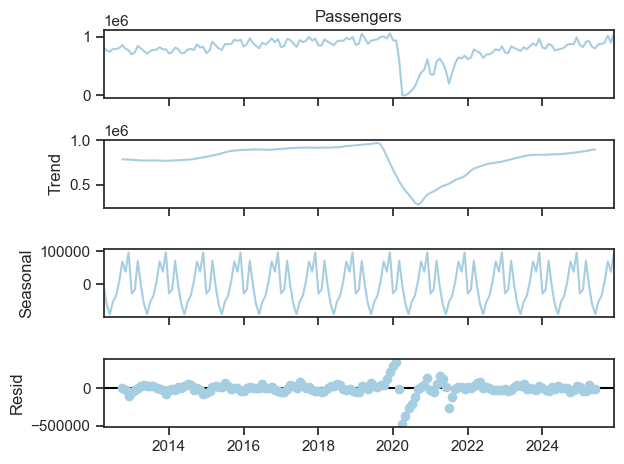

In [1094]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Verifying seasonality (12 months)
season = seasonal_decompose(df['Passengers'],
                            model='additive', period=12)
season.plot()

Text(0.5, 1.0, 'Monthly Passengers')

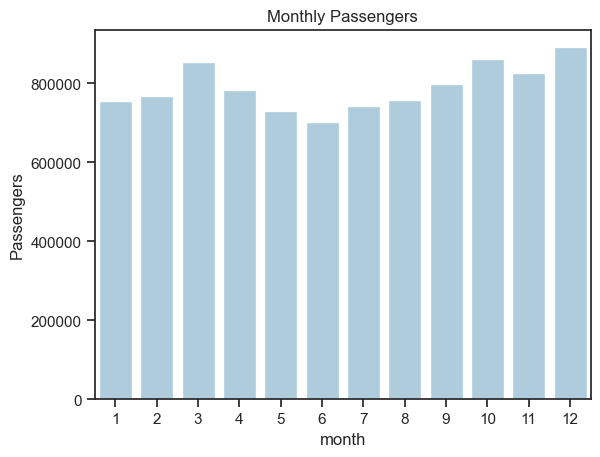

In [1246]:
sns.barplot(df, x ='month', y='Passengers',
           errorbar=None)
plt.title('Monthly Passengers')

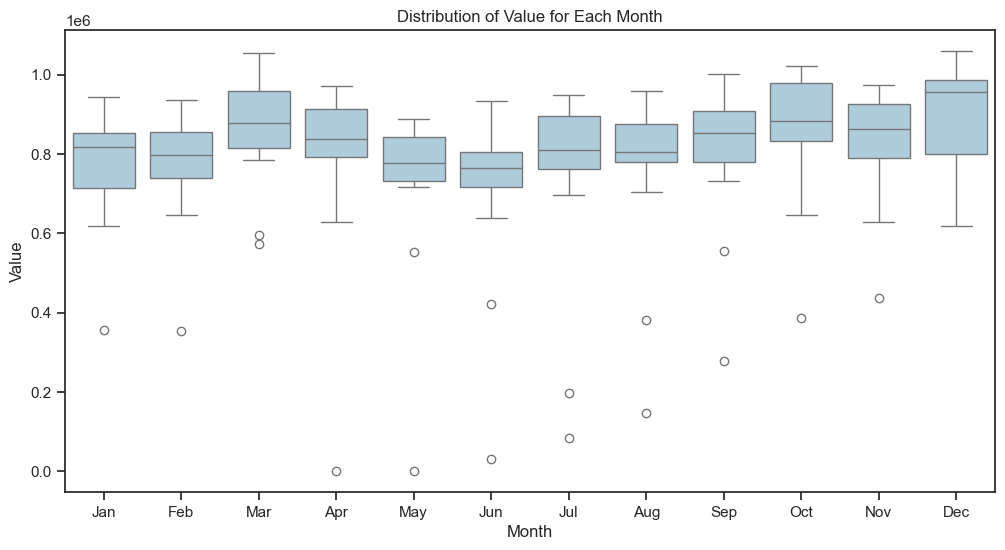

In [1244]:
import calendar
df['month_name'] = df['month'].apply(lambda x: calendar.month_abbr[x])
month_order = [calendar.month_abbr[i] for i in range(1, 13)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='month_name', y='Passengers', data=df,
            order=month_order)
plt.title('Distribution of Value for Each Month')
plt.xlabel('Month')
plt.ylabel('Value')
plt.show()


## **BAISE NAIVE**

In [1096]:
df_naive = df[['Passengers']]

In [1097]:
naive_train = df_naive.iloc[ :133]
naive_test = df_naive.iloc[133: ]

In [1098]:
naive_train['Passengers_t-1'] = naive_train['Passengers'].shift(1)

## Keeping row from 1 (since after shifting we have our first row as NULL)
naive_train = naive_train[['Passengers','Passengers_t-1']][1:]

In [1099]:
from math import sqrt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error 

naive_rmse=sqrt(mean_squared_error(naive_train['Passengers_t-1'],naive_train['Passengers']))
nive_mape = mean_absolute_percentage_error(naive_train['Passengers_t-1'], naive_train['Passengers'])
print(r2_score(naive_train['Passengers_t-1'], naive_train['Passengers']))
print("RMSE:", naive_rmse)


y_true_arr = np.array(naive_train['Passengers']).flatten()
y_pred_arr = np.array(naive_train['Passengers_t-1']).flatten()

mask = y_true_arr != 0
y_true_filtered = y_true_arr[mask]
y_pred_filtered = y_pred_arr[mask]



# Re-calculate MAPE on the filtered data
clean_mape = mean_absolute_percentage_error(y_true_filtered, y_pred_filtered)
print(f"Filtered MAPE: {clean_mape:.4f}")

0.7856590315638807
RMSE: 98307.92372851034
Filtered MAPE: 0.1114


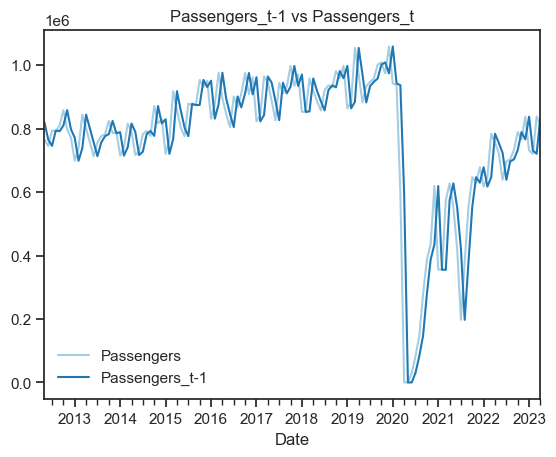

In [1100]:
naive_train['Passengers'].plot(legend=True)
naive_train['Passengers_t-1'].plot(legend=True)

plt.title("Passengers_t-1 vs Passengers_t")
plt.show()

## **SARIMAX**

In [961]:
#importing SARIMA and ARIMA 
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_squared_error, r2_score



In [962]:
df_sarima = df[['Passengers']]

#### **SARIMA**

In [874]:
X_sarima_train = df_sarima.iloc[ :133]
X_sarima_test = df_sarima.iloc[133: ]

In [875]:
from statsmodels.tsa.stattools import adfuller
test_result=adfuller(X_sarima_train['Passengers'])

In [876]:
#HYPOTHESIS TEST:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(passenger):
    result=adfuller(passenger)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

Test stationarity for original series
-------------------------------------
ADF Test Statistic : -1.6880675938993286
p-value : 0.43727066036087026
#Lags Used : 13
Number of Observations Used : 119
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 
None

Test stationarity for differenced series (order=1)
--------------------------------------------------
ADF Test Statistic : -3.1599941332646106
p-value : 0.022420334631182127
#Lags Used : 13
Number of Observations Used : 118
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary
None

Test stationarity for differenced series (order=2)
--------------------------------------------------
ADF Test Statistic : -6.306634950441867
p-value : 3.311218539020875e-08
#Lags Used : 13
Number of Observations Used : 117
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary
None


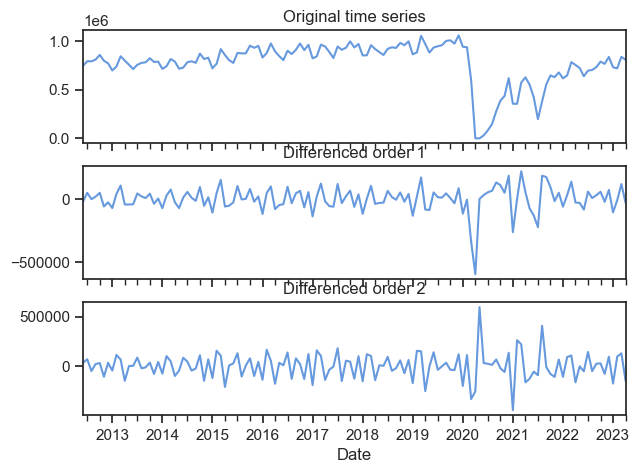

In [877]:
#differencing and stationary testing
X_sarima_train_diff1 = X_sarima_train['Passengers'].diff().dropna()
X_sarima_train_diff2 = X_sarima_train_diff1.diff().dropna()

with warnings.catch_warnings():
    warnings.filterwarnings('ignore')
    print('Test stationarity for original series')
    print('-------------------------------------')
    print(adfuller_test(X_sarima_train['Passengers']))

    print('\nTest stationarity for differenced series (order=1)')
    print('--------------------------------------------------')
    print(adfuller_test(X_sarima_train_diff1))
    
    print('\nTest stationarity for differenced series (order=2)')
    print('--------------------------------------------------')
    print(adfuller_test(X_sarima_train_diff2))

# Plot series
# ==============================================================================
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(7, 5), sharex=True)
X_sarima_train['Passengers'].plot(ax=axs[0], title='Original time series')
X_sarima_train_diff1.plot(ax=axs[1], title='Differenced order 1')
X_sarima_train_diff2.plot(ax=axs[2], title='Differenced order 2');

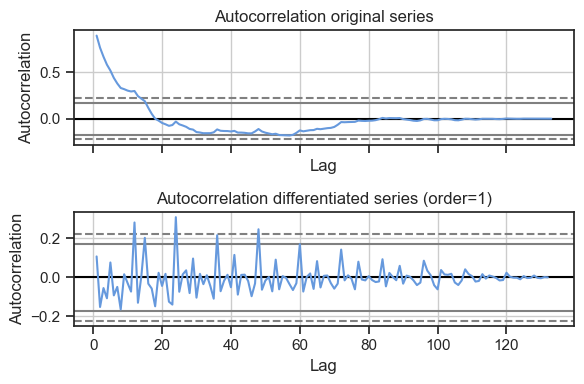

In [878]:
#autocorrelation_plot
# Autocorrelation plot for original and differentiated series
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True)
autocorrelation_plot(X_sarima_train['Passengers'], ax=axs[0])
axs[0].set_title('Autocorrelation original series')

# Autocorrelation plot for original and differentiated series
autocorrelation_plot(X_sarima_train_diff1, ax=axs[1])
axs[1].set_title('Autocorrelation differentiated series (order=1)');

plt.tight_layout()

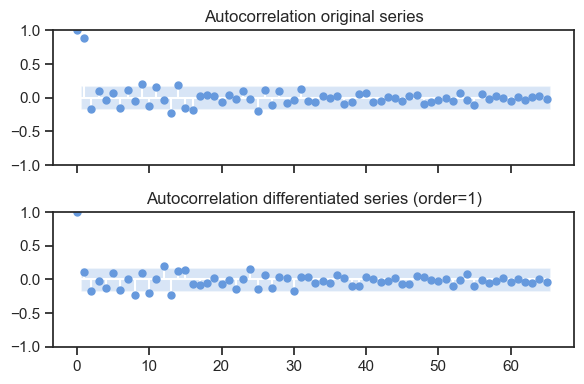

In [879]:
# Autocorrelation plot for original and differentiated series
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True)
plot_pacf(X_sarima_train['Passengers'], ax=axs[0], method='ywm',lags=65)
axs[0].set_title('Autocorrelation original series')
plot_pacf(X_sarima_train_diff1, ax=axs[1], method='ywm', lags=65)
axs[1].set_title('Autocorrelation differentiated series (order=1)');

plt.tight_layout()

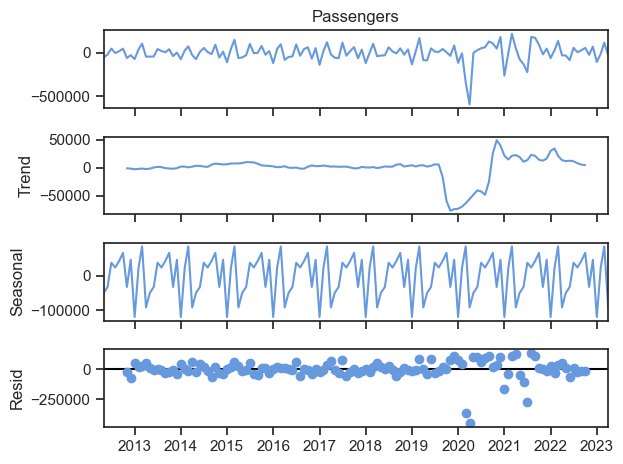

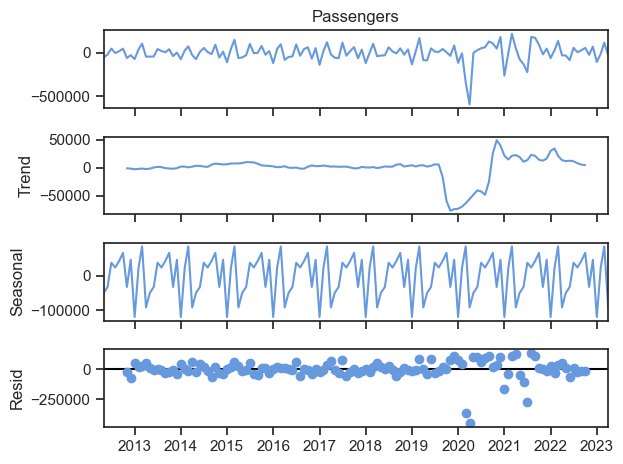

In [880]:
# Verifying seasonality (12 months)
season = seasonal_decompose(X_sarima_train_diff1.asfreq("MS"), model='additive')
season.plot(season)

In [881]:
# First-order differentiation combined with seasonal differentiation
data_diff_1_12 = X_sarima_train.diff().diff(12).dropna()

warnings.filterwarnings("ignore")
adfuller_result = adfuller(data_diff_1_12)
print(f'ADF Statistic: {adfuller_result[0]}, p-value: {adfuller_result[1]}')

ADF Statistic: -4.0365076633142065, p-value: 0.0012309599067719377


In [882]:
sarimax = SARIMAX(df_sarima['Passengers'], order =(1,1,1),
                  seasonal_order=(1,1,1,12))
jnb_result = sarimax.fit()

start = len(X_sarima_train)
end = len(X_sarima_train) + len(X_sarima_test)-1
predict_sarima1 = jnb_result.predict(start, end).rename('prediction')

In [883]:
predict_sarima1.shape, X_sarima_test.shape

((32,), (32, 1))

In [884]:
# Ensuring the index of both is datetime
X_sarima_test.index = pd.to_datetime(X_sarima_test.index)
predict_sarima1.index = pd.to_datetime(predict_sarima1.index)

# Sorting the indexes
X_sarima_test = X_sarima_test.sort_index()
predict_sarima1 = predict_sarima1.sort_index()

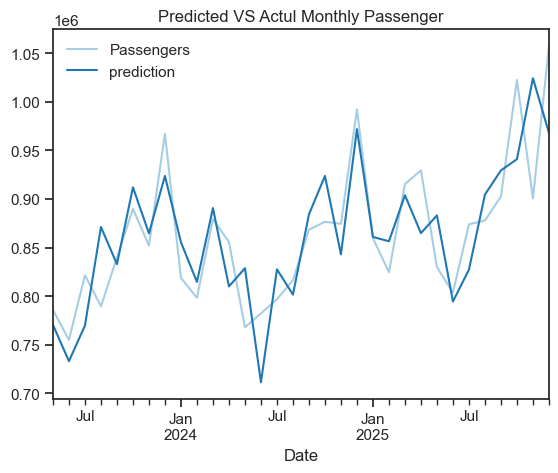

In [1112]:
#plotting actuals vs predicted Passengers
X_sarima_test['Passengers'].plot(legend=True)
predict_sarima1.plot(legend=True)

plt.title("Predicted VS Actul Monthly Passenger");

In [886]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error
from math import sqrt

#Evaluating the model
sarima_rmse = sqrt(mean_squared_error(X_sarima_test.Passengers, np.array(predict_sarima1)))
sarima_mape = mean_absolute_percentage_error(X_sarima_test.Passengers,np.array(predict_sarima1))
sarima_mae = mean_absolute_error(X_sarima_test.Passengers, np.array(predict_sarima1))
sarima_r2_score = r2_score(X_sarima_test.Passengers,  np.array(predict_sarima1))


In [887]:
metrics = {
    'RMSE': sarima_rmse,
    'MAPE': sarima_mape,
    'MAE' : sarima_mae,
    'sarima_r2_score': sarima_r2_score
}

# Display as table
df_metrics = pd.DataFrame([metrics])
df_metrics

,RMSE,MAPE,MAE,sarima_r2_score
0,47427.036773,0.04397,38247.899262,0.556415


In [888]:
future_dates_jnb = pd.date_range(start=df.index[-1], periods=25, freq='M')[1:]
jnb_forecast = pd.Series(jnb_result.forecast(steps=24).values, index=future_dates_jnb).to_frame(name='forecast')


<Figure size 1200x700 with 0 Axes>

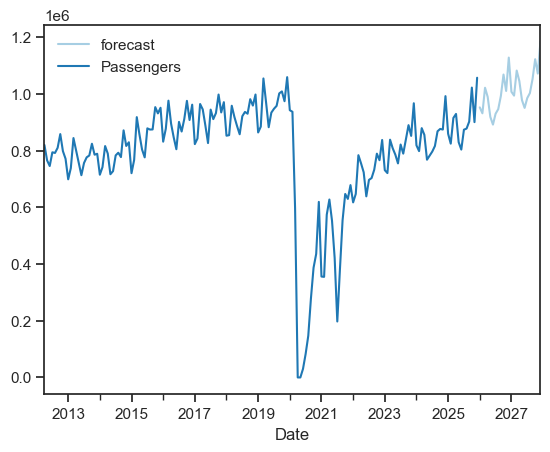

In [1113]:
fig = plt.figure(figsize=(12,7))
jnb_forecast.plot()
df['Passengers'].plot(legend=True)
plt.show()

#### **SARIMAX**

In [946]:
df_exog = df[['cpi', 'gdp_per_capta', 'tourists', 'Passengers']]

In [948]:
X_exog_train = df_exog.iloc[ :133]
X_exog_test = df_exog.iloc[133: ]

In [1135]:
mod = SARIMAX((X_exog_train['Passengers']), 
              exog=X_exog_train[['cpi', 'gdp_per_capta', 'tourists', 'covid_binary']],
             order=(1,1,1), seasonal_order=(1,1,1,12))
result_exog= mod.fit()

prediction_exog = result_exog.predict(
    start = len(X_exog_train),
    end = len(X_exog_train) + len(X_exog_test)-1, 
    exog=X_exog_test[['cpi', 'gdp_per_capta', 'tourists', 'covid_binary']]).rename('Prediction')



In [1136]:
# Ensuring the index of both is datetime
X_exog_train.index = pd.to_datetime(X_exog_train.index)
prediction_exog.index = pd.to_datetime(prediction_exog.index)

# Sorting the indexes
test_post_exog = X_exog_train.sort_index()
prediction_exog = prediction_exog.sort_index()

In [1137]:
test_post_exog.shape, prediction_exog.shape

((133, 6), (32,))

<Axes: xlabel='Date'>

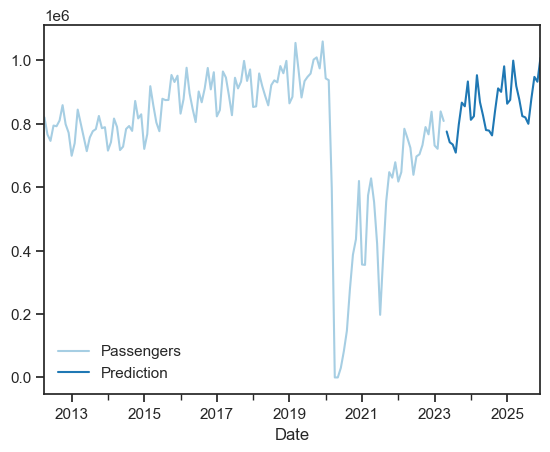

In [1138]:
X_exog_train['Passengers'].plot(legend=True)
prediction_exog.plot(legend=True)

In [1159]:
#Evaluating the SARIMA model
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score,mean_absolute_percentage_error,mean_absolute_error


rmse_exog = sqrt(mean_squared_error(X_exog_test['Passengers'], np.array(prediction_exog)))
mpe_exog = mean_absolute_percentage_error(np.array(prediction_exog), X_exog_test['Passengers'])
r2_score_exog = r2_score(np.array(prediction_exog), X_exog_test['Passengers'])
mae_exog = mean_absolute_error(X_exog_test['Passengers'], np.array(prediction_exog))

In [1140]:
metrics = {
    'RMSE': rmse_exog,
    'MAPE': mpe_exog,
    'MAE' : mae_exog,
    'R2_Score': r2_score_exog }

# Displaying as table
df_metrics = pd.DataFrame([metrics])
df_metrics

,RMSE,MAPE,MAE,R2_Score
0,44897.315215,0.043172,36628.219513,0.65801


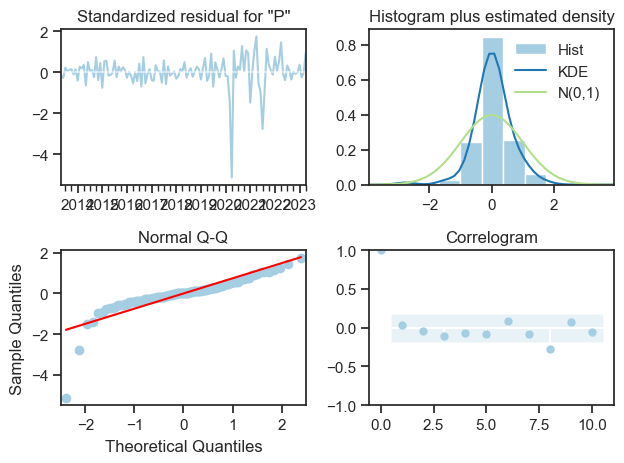

In [1141]:
result_exog.plot_diagnostics()
plt.tight_layout()

## **XGBOOST**

In [772]:
df_xg = df.copy()
df_xg.head()

,Passengers,tourists,crude_oil
Date,,,
2012-04-01,819885.0,802834.0,890.44
2012-05-01,765773.0,692046.0,846.60
2012-06-01,745731.0,653686.0,761.13
2012-07-01,794131.0,793245.0,798.05
2012-08-01,791901.0,77562.0,871.23


In [773]:
df_xg1 = df_xg.copy()
df_xg1=df_xg1.asfreq('MS')

In [774]:
#train and test sets
df_train_xg1 = df_xg1[:132]
df_test_xg1 = df_xg1[132:]

In [775]:
from skforecast.preprocessing import RollingFeatures
window_features = RollingFeatures(
    stats=["mean", "std", "max"], 
    window_sizes=[24, 24, 24]
)

In [776]:
from xgboost import XGBRegressor
from skforecast.recursive import ForecasterRecursive

forecaster = ForecasterRecursive(
                estimator       = XGBRegressor(enable_categorical=True),
                lags            = 25,
                window_features = window_features
                
             )

# Train forecaster
# ==============================================================================
forecaster.fit(y=df_train_xg1['Passengers'])
forecaster



=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25] 
Window features: ['roll_mean_24', 'roll_std_24', 'roll_max_24'] 
Window size: 25 
Series name: Passengers 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2012-04-01 00:00:00'), Timestamp('2023-03-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': True, 'eval_metric': None, 'feature_types': None,
    'gamma': None, 'grow_policy': None, 'importance_type': None,
    'interaction_constraints': None, 'learning_rate': None, 'max_bin': None,
    'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step':
    None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None,
    'missing': nan, 'monotone_constraints': None, 'multi_strategy': None,
    'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None,
    'random_state': None, 'reg_alpha': None, 'reg_lambda': None,
    'sampling_method': None, 'scale_pos_weight': None, 'subsample': None,
    'tree_method': None, 'validate_parameters': None, 'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-03-06 10:32:12 
Last fit date: 2026-03-06 10:32:12 
Skforecast version: 0.19.0 
Python version: 3.12.5 
Forecaster id: None

In [777]:
pred = forecaster.predict(steps=33)


<Axes: xlabel='Date'>

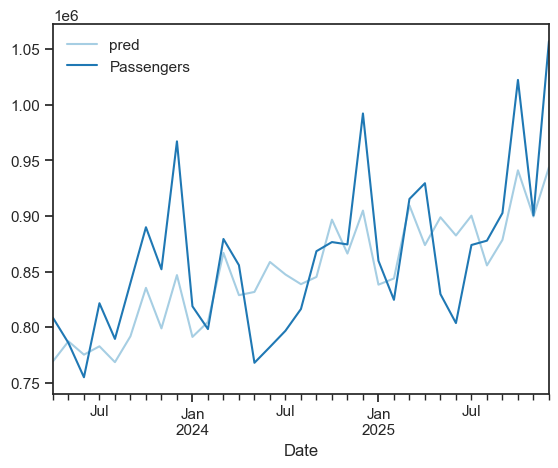

In [1248]:
pred.plot(legend=True)
df_test_xg1['Passengers'].plot(legend=True)

In [710]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mean_absolute_error(y_true=df_test_xg1['Passengers'],
                   y_pred=pred)

40620.895833333336

In [718]:
#Back seating
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_forecaster

cv = TimeSeriesFold(
        steps              = 12,
        initial_train_size = 120,
        refit              = True,
)

def weighted_absolute_percentage_error(y_true, y_pred):
    """
    Custom WAPE metric for data with zeros.
    """
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

metric, predictions = backtesting_forecaster(
    forecaster = forecaster,
    y          = df_train_xg1['Passengers'],
    cv         = cv,
    metric     = ['mean_squared_error', weighted_absolute_percentage_error, 'mean_absolute_error']
)

metric

  0%|          | 0/1 [00:00<?, ?it/s]

,mean_squared_error,weighted_absolute_percentage_error,mean_absolute_error
0,4.182510e+09,0.078137,58175.098958


<Axes: xlabel='Date'>

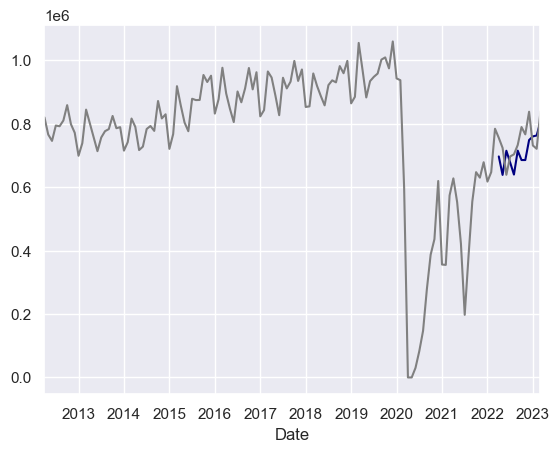

In [719]:
predictions['pred'].plot()
df_train_xg1['Passengers'].plot()

#### **Exogeneous Variables**

In [723]:
import holidays

daily_rng = pd.date_range(start='2012-04-01', end='2025-12-01', freq='D')
us_holidays = holidays.ZA()

# 2. Map holidays to the daily range
df_daily = pd.DataFrame(index=daily_rng)
df_daily['is_holiday'] = df_daily.index.map(lambda x: 1 if x in us_holidays else 0)

# 3. Resample to Month Start ("MS") frequency
# Summing gives "Holiday Count" per month
df_monthly_holidays = df_daily['is_holiday'].resample('MS').sum().to_frame()
df_monthly_holidays['Month'] = df.index.month
df_monthly_holidays['Year'] = df.index.year

#Covid19 dummy
target_dates = df_monthly_holidays.index[(df_monthly_holidays.index >='2020-03-01') & (df_monthly_holidays.index < '2021-08-01')]
target_dates2 = df_monthly_holidays.index[(df_monthly_holidays.index >='2013-03-01') & (df_monthly_holidays.index < '2014-02-01')]

# Create the dummy column
df_monthly_holidays['covid_binary'] = df_monthly_holidays.index.isin(target_dates).astype(int)
df_monthly_holidays['bankrupsy_binary'] = df_monthly_holidays.index.isin(target_dates2).astype(int)

df_monthly_holidays.head()

,is_holiday,Month,Year,covid_binary,bankrupsy_binary
2012-04-01,3,4,2012,0,0
2012-05-01,1,5,2012,0,0
2012-06-01,1,6,2012,0,0
2012-07-01,0,7,2012,0,0
2012-08-01,1,8,2012,0,0


In [724]:
df_monthly_holidays['covid_binary'].value_counts()

covid_binary
0    148
1     17
Name: count, dtype: int64

In [725]:
df_monthly_holidays['bankrupsy_binary'].value_counts()

bankrupsy_binary
0    154
1     11
Name: count, dtype: int64

In [726]:
merged_df = pd.merge(df_xg1, df_monthly_holidays, left_index=True, right_index=True, how='inner')
merged_df=merged_df.asfreq('MS')

In [727]:
from sklearn.preprocessing import FunctionTransformer

# Cyclical encoding with sine/cosine transformation
def sin_transformer(period):
	return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))

def cos_transformer(period):
	return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

data_encoded_sin_cos = merged_df.copy()
data_encoded_sin_cos["month_sin"] = sin_transformer(12).fit_transform(merged_df['Month'])
data_encoded_sin_cos["month_cos"] = cos_transformer(12).fit_transform(merged_df['Month'])
data_encoded_sin_cos.head()

,Passengers,tourists,crude_oil,is_holiday,Month,Year,covid_binary,bankrupsy_binary,month_sin,month_cos
Date,,,,,,,,,,
2012-04-01,819885.0,802834.0,890.44,3,4,2012,0,0,8.660254e-01,-0.500000
2012-05-01,765773.0,692046.0,846.60,1,5,2012,0,0,5.000000e-01,-0.866025
2012-06-01,745731.0,653686.0,761.13,1,6,2012,0,0,1.224647e-16,-1.000000
2012-07-01,794131.0,793245.0,798.05,0,7,2012,0,0,-5.000000e-01,-0.866025
2012-08-01,791901.0,77562.0,871.23,1,8,2012,0,0,-8.660254e-01,-0.500000


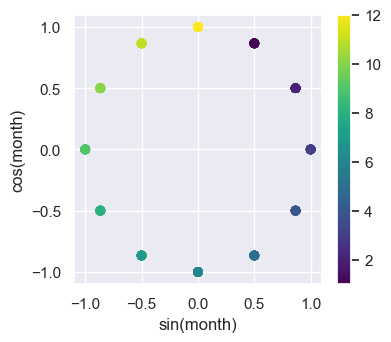

In [728]:
fig, ax = plt.subplots(figsize=(4., 3.5))
sp = ax.scatter(
        data_encoded_sin_cos["month_sin"],
        data_encoded_sin_cos["month_cos"],
        c=data_encoded_sin_cos["Month"],
        cmap='viridis'
     )
ax.set(
    xlabel="sin(month)",
    ylabel="cos(month)",
)
_ = fig.colorbar(sp)
data_encoded_sin_cos = data_encoded_sin_cos.drop(columns='Month')

In [729]:
# Assuming 'df' has a DatetimeIndex with 'MS' frequency
data_encoded_sin_cos['oil_roll_mean_3M'] = data_encoded_sin_cos['crude_oil'].rolling(window=3).mean()
data_encoded_sin_cos['oil_roll_mean_1Y'] = data_encoded_sin_cos['crude_oil'].rolling(window=12).mean()
data_encoded_sin_cos['tourists_roll_mean_3M'] = data_encoded_sin_cos['tourists'].rolling(window=3).mean()
data_encoded_sin_cos['tourists_roll_mean_1Y'] = data_encoded_sin_cos['tourists'].rolling(window=12).mean()

In [730]:
#train and test sets
df_train_xg2 = data_encoded_sin_cos[:132]
df_test_xg2 = data_encoded_sin_cos[132:]

In [731]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fits to data and transforms it in one step
scaled_data = scaler.fit_transform(df_train_xg2)

In [732]:
df_train_xg2.columns

Index(['Passengers', 'tourists', 'crude_oil', 'is_holiday', 'Year',
       'covid_binary', 'bankrupsy_binary', 'month_sin', 'month_cos',
       'oil_roll_mean_3M', 'oil_roll_mean_1Y', 'tourists_roll_mean_3M',
       'tourists_roll_mean_1Y'],
      dtype='object')

In [759]:
exog_features = ['oil_roll_mean_3M', 'oil_roll_mean_1Y','bankrupsy_binary','is_holiday', 'covid_binary',
                 'month_sin', 'month_cos', 'tourists_roll_mean_3M','tourists_roll_mean_1Y' ]

In [760]:
from xgboost import XGBRegressor
from skforecast.model_selection import backtesting_forecaster

def weighted_absolute_percentage_error(y_true, y_pred):
    """
    Custom WAPE metric for data with zeros.
    """
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

metric, predictions = backtesting_forecaster(
                forecaster= forecaster,
                y = df_train_xg2['Passengers'],
                exog = data_encoded_sin_cos[exog_features],
                cv = cv,
                metric = [weighted_absolute_percentage_error, 'mean_absolute_error']
             )



  0%|          | 0/1 [00:00<?, ?it/s]

In [761]:
metric

,weighted_absolute_percentage_error,mean_absolute_error
0,0.046956,34959.947917


<Axes: xlabel='Date'>

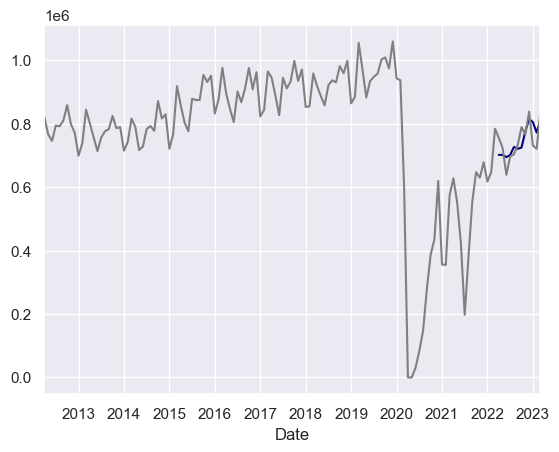

In [762]:
predictions['pred'].plot()
df_train_xg2['Passengers'].plot()

<Axes: xlabel='Date'>

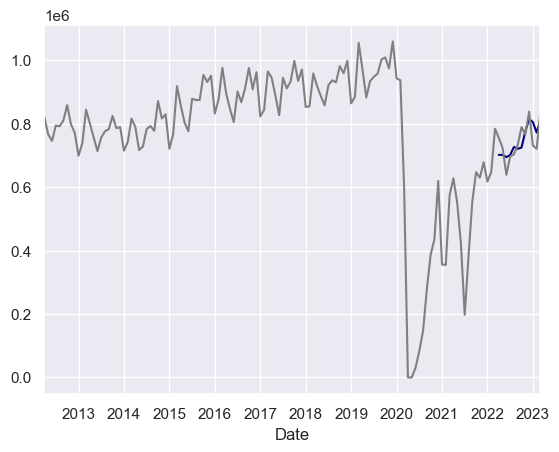

In [763]:
predictions['pred'].plot()
df_train_xg2['Passengers'].plot()

In [1165]:
# Hyperparameters search
from skforecast.model_selection import bayesian_search_forecaster

# Lags grid
lags_grid = [48, 72, [1, 2, 3, 23, 24, 25]]

# Estimator hyperparameters search space
def search_space(trial):
    search_space  = {
        'n_estimators'    : trial.suggest_int('n_estimators', 400, 1200, step=100),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 1),
        'subsample'       : trial.suggest_float('subsample', 0.1, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1),
        'gamma'           : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0, 1),
        'lags'            : trial.suggest_categorical('lags', lags_grid)
    } 
    return search_space

# Folds
cv_searh = TimeSeriesFold(
                steps              = 12,
                initial_train_size = 120,
                refit              = True,
            )
def weighted_absolute_percentage_error(y_true, y_pred):
    """
    Custom WAPE metric for data with zeros.
    """
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    
results_search, frozen_trial = bayesian_search_forecaster(
                                    forecaster= forecaster,
                                    y = df_train_xg2['Passengers'],
                                    exog = df_train_xg2[exog_features],
                                    search_space = search_space,
                                    cv           = cv_searh,
                                    metric       = ['mean_absolute_error', weighted_absolute_percentage_error],
                                    n_trials     = 20
                                )
best_params = results_search['params'].iat[0]
best_lags = results_search['lags'].iat[0]


  0%|          | 0/20 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 23 24 25] 
  Parameters: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.31913861074274064, 'subsample': 0.4837161762665274, 'colsample_bytree': 0.9040502468054213, 'gamma': 0.9441600182038796, 'reg_alpha': 0.5018366758843366, 'reg_lambda': 0.6239529517921112}
  Backtesting metric: 34959.947916666664


In [738]:
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 
Window features: ['roll_mean_24', 'roll_std_24', 'roll_max_24'] 
Window size: 72 
Series name: Passengers 
Exogenous included: True 
Exogenous names: 
    oil_roll_mean_3M, oil_roll_mean_1Y, crude_oil, tourists, bankrupsy_binary,
    is_holiday, covid_binary, month_sin, month_cos, tourists_roll_mean_3M,
    tourists_roll_mean_1Y 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2012-04-01 00:00:00'), Timestamp('2023-03-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': 0.8654126885819307, 'device': 'cpu',
    'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric':
    None, 'feature_types': None, 'gamma': 0.8648896334089385, 'grow_policy':
    None, 'importance_type': None, 'interaction_constraints': None,
    'learning_rate': 0.12636547233014567, 'max_bin': None, 'max_cat_threshold':
    None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4,
    'max_leaves': None, 'min_child_weight': None, 'missing': nan,
    'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1200,
    'n_jobs': None, 'num_parallel_tree': None, 'random_state': None,
    'reg_alpha': 0.5267718309237392, 'reg_lambda': 0.808286523261457,
    'sampling_method': None, 'scale_pos_weight': None, 'subsample':
    0.2920091802957757, 'tree_method': None, 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-03-06 08:47:28 
Last fit date: 2026-03-06 09:28:29 
Skforecast version: 0.19.0 
Python version: 3.12.5 
Forecaster id: None

In [1187]:
# Backtesting model with exogenous variables on test data

def weighted_absolute_percentage_error(y_true, y_pred):
    """
    Custom WAPE metric for data with zeros.
    """
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.mean(np.square(y_true - y_pred)))
    
metric, predictions = backtesting_forecaster(
                            forecaster = forecaster,
                            y          = data_encoded_sin_cos['Passengers'],
                            exog = data_encoded_sin_cos[exog_features],
                            cv         = cv,
                            metric     = [weighted_absolute_percentage_error, root_mean_squared_error,
                                          'mean_absolute_error', r2_score]
                       )
display(metric)
predictions.head()

  0%|          | 0/4 [00:00<?, ?it/s]

,weighted_absolute_percentage_error,root_mean_squared_error,mean_absolute_error,r2_score
0,0.045127,45671.441146,37473.2125,0.708874


,fold,pred
2022-04-01,0,701648.0000
2022-05-01,0,701442.7500
2022-06-01,0,694706.1875
2022-07-01,0,701157.5625
2022-08-01,0,726622.3125


<Axes: xlabel='Date'>

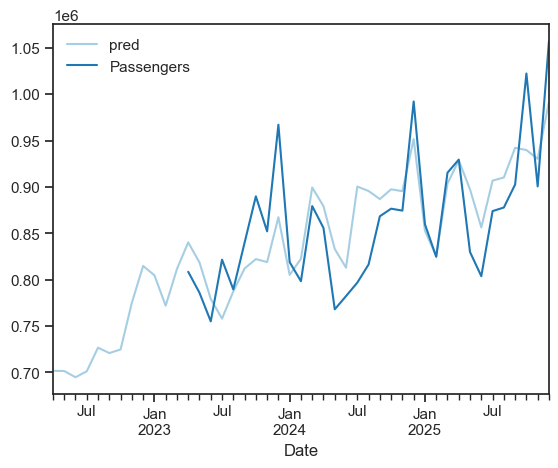

In [1249]:
predictions['pred'].plot(legend = True)
df_test_xg2['Passengers'].plot(legend = True)

## **RESULTS**

In [1215]:
#Naive
naive_rmse=sqrt(mean_squared_error(naive_train['Passengers_t-1'],naive_train['Passengers']))
naive_r2_score = r2_score(naive_train['Passengers'], naive_train['Passengers_t-1'])
naive_mae = mean_absolute_error(naive_train['Passengers_t-1'], naive_train['Passengers'])

y_true_filtered = y_true_arr[mask]
y_pred_filtered = y_pred_arr[mask]
#MAPE on the filtered data
naive_mape = mean_absolute_percentage_error(y_true_filtered, y_pred_filtered)

#SARIMA
sarima_rmse = sqrt(mean_squared_error(X_sarima_test.Passengers, np.array(predict_sarima1)))
sarima_mape = mean_absolute_percentage_error(X_sarima_test.Passengers,np.array(predict_sarima1))
sarima_mae = mean_absolute_error(X_sarima_test.Passengers, np.array(predict_sarima1))
sarima_r2_score = r2_score(X_sarima_test.Passengers,  np.array(predict_sarima1))

#SARIMAX
rmse_exog = sqrt(mean_squared_error(X_exog_test['Passengers'], np.array(prediction_exog)))
mpe_exog = mean_absolute_percentage_error(np.array(prediction_exog), X_exog_test['Passengers'])
r2_score_exog = r2_score(np.array(prediction_exog), X_exog_test['Passengers'])
mae_exog = mean_absolute_error(X_exog_test['Passengers'], np.array(prediction_exog))

#XGBOOST
xg_rmse = metric.values[0][1]
xg_mape = metric.values[0][0]
xg_mae = metric.values[0][-2]
xg_r2score = metric.values[0][-1]


In [1250]:
all_metrics = [
    { 'MODEL': 'Naive Bayes', 'RMSE': naive_rmse, 'MAPE': naive_mape, 'MAE': naive_mae, 'r2_score': naive_r2_score },
    { 'MODEL': 'SARIMA', 'RMSE': sarima_rmse, 'MAPE': sarima_mape, 'MAE' : sarima_mae ,'r2_score': sarima_r2_score },
    { 'MODEL': 'SARIMAX', 'RMSE': rmse_exog, 'MAPE': mpe_exog, 'MAE' : mae_exog ,'r2_score': r2_score_exog },
    { 'MODEL': 'XGBOOST', 'RMSE': xg_rmse, 'MAPE': xg_mape, 'MAE' : xg_mae ,'r2_score': xg_r2score },
    ]

# Display as DataFrame
df_metrics = pd.DataFrame(all_metrics)
df_metrics

,MODEL,RMSE,MAPE,MAE,r2_score
0,Naive Bayes,98307.923729,0.111449,67003.492424,0.785624
1,SARIMA,47427.036773,0.043970,38247.899262,0.556415
2,SARIMAX,44897.315215,0.043172,36628.219513,0.658010
3,XGBOOST,45671.441146,0.045127,37473.212500,0.708874
